In [1]:
!pip show numpy

Name: numpy
Version: 2.5.3
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License-Expression: BSD-3-Clause AND 0BSD AND MIT AND Zlib AND CC0-1.0
Location: D:\programming\ML\my_simple_models\.venv\Lib\site-packages
Requires: 
Required-by: contourpy, matplotlib, pandas


In [2]:
import numpy as np

In [71]:
x = np.linspace(-40, 40, 20)

rng = np.random.default_rng(1234)
y = 32 * x + 3 + rng.normal(0, 10, 20)

w_true, b_true = 32, 3

y_clean = w_true * x + b_true
y = y_clean + rng.normal(0, 5, x.shape)

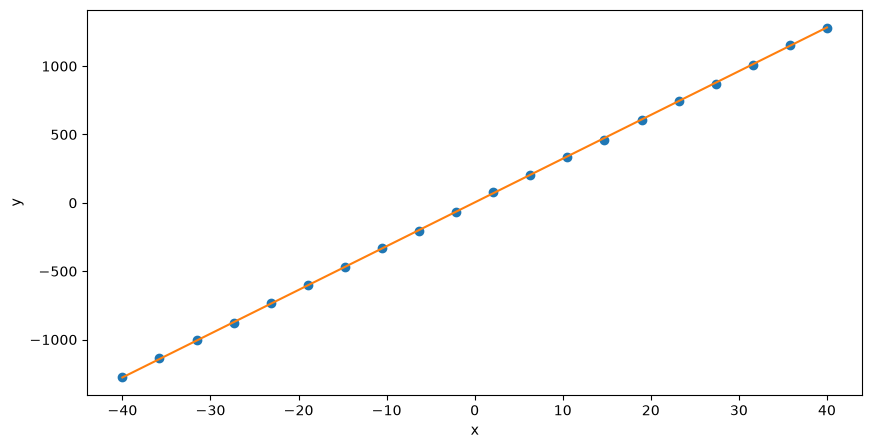

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(x, y, "o")
plt.plot(x, y_clean, "-")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [73]:
def MSE(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

class MyLinearRegression:
    def __init__(self):
        self.w = 1
        self.b = 1

    def forward(self, x):
        return self.w * x + self.b

    def backward(self, x, lr, dL_ds):
        dL_dw = np.mean(dL_ds * -x)
        dL_db = np.mean(dL_ds * -1)

        self.w -= dL_dw * lr
        self.b -= dL_db * lr

    def get_params(self):
        return self.w, self.b

In [76]:
def fit(model, X, y_true, epochs=2000, lr=0.001):
    for epoch in range(epochs):
        y_pred = model.forward(X)
        loss = MSE(y_true, y_pred)

        dL_ds = 2 * (y_true - y_pred)
        model.backward(X, lr, dL_ds)

        print(f"Epoch: {epoch}, Loss: {loss}")
        print(f"Params: {model.get_params()}")

In [77]:
model = MyLinearRegression()
fit(model, x, y)

Epoch: 0, Loss: 563653.5581004279
Params: (np.float64(37.45531765217027), np.float64(1.0019990276536725))
Epoch: 1, Loss: 18068.109690366422
Params: (np.float64(30.93173449336086), np.float64(1.0039940572520378))
Epoch: 2, Loss: 597.2809566648309
Params: (np.float64(32.0991125323057), np.float64(1.0059850967912065))
Epoch: 3, Loss: 37.82343905780913
Params: (np.float64(31.890213304283993), np.float64(1.0079721542512967))
Epoch: 4, Loss: 19.904582911439636
Params: (np.float64(31.927595271403668), np.float64(1.0099552375964667))
Epoch: 5, Loss: 19.326980043834663
Params: (np.float64(31.9209058667612), np.float64(1.0119343547749464))
Epoch: 6, Loss: 19.304696769150652
Params: (np.float64(31.92210291811827), np.float64(1.0139095137190692))
Epoch: 7, Loss: 19.300211161274085
Params: (np.float64(31.92188870892806), np.float64(1.0158807223453037))
Epoch: 8, Loss: 19.296310546252315
Params: (np.float64(31.92192704109894), np.float64(1.0178479885542857))
Epoch: 9, Loss: 19.292443676842908
Param

In [78]:
def fit_SGD(model, X, y_true, epochs=1000, lr=0.001, batch_size=10, shuffle=True):
    for epoch in range(epochs):
        if shuffle:
            idx = rng.permutation(len(X))
            X, y_true = X[idx], y_true[idx]

        epoch_loss = 0

        for i in range(0, len(X), batch_size):
            batch_X = X[i:i+batch_size]
            batch_y = y_true[i:i+batch_size]

            y_pred = model.forward(batch_X)
            loss = MSE(batch_y, y_pred)
            epoch_loss += loss

            dL_ds = 2 * (batch_y - y_pred)
            model.backward(batch_X, lr, dL_ds)

        print(f"Epoch: {epoch}, Loss: {epoch_loss / (len(X) / batch_size)}")
        print(f"Params: {model.get_params()}")

In [80]:
model = MyLinearRegression()
fit_SGD(model, x, y, epochs=1000, lr=0.0001, batch_size=16, shuffle=True)

Epoch: 0, Loss: 598119.799401436
Params: (np.float64(5.906171378799339), np.float64(0.9685746343569056))
Epoch: 1, Loss: 534717.2128046919
Params: (np.float64(11.31573177030531), np.float64(0.9348854181039618))
Epoch: 2, Loss: 379044.6873105997
Params: (np.float64(16.203950479361723), np.float64(0.9411097939246614))
Epoch: 3, Loss: 250070.2572772391
Params: (np.float64(20.45770586057143), np.float64(0.9135746230581112))
Epoch: 4, Loss: 113928.51862842741
Params: (np.float64(23.094545308108888), np.float64(0.8971831733560077))
Epoch: 5, Loss: 59202.27465560702
Params: (np.float64(24.85516185396884), np.float64(0.8941721848055707))
Epoch: 6, Loss: 42431.58567402927
Params: (np.float64(26.43827744441471), np.float64(0.8802209315387707))
Epoch: 7, Loss: 21968.86934458
Params: (np.float64(27.47961244559768), np.float64(0.8822022320648908))
Epoch: 8, Loss: 16876.59437446493
Params: (np.float64(28.478019370336863), np.float64(0.8885691500662811))
Epoch: 9, Loss: 8528.170689311668
Params: (np.